## TASK 1 (AND TASK 0)


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from tqdm import tqdm
import os

In [8]:
# fix random seeds for reproducibility
np.random.seed(1)
torch.manual_seed(1)

### Load and Process Data

In [9]:
batch_size=128

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

dataset1 = datasets.MNIST("data", train=True, download=True, transform=transform)
dataset2 = datasets.MNIST("data", train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset1, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(dataset2, batch_size=batch_size)

<function matplotlib.pyplot.show(close=None, block=None)>

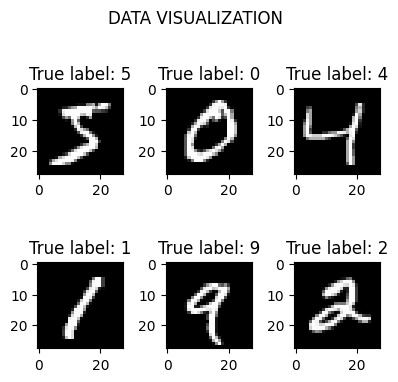

In [10]:
# Visualise data we are working with

# Create a 2x2 grid of subplots
fig, axes= plt.subplots(2,3, figsize=(4,4))
#title
fig.suptitle('DATA VISUALIZATION', fontsize=12)

#loop over the first 6 images in the dataset
for i, ax in enumerate(axes.flatten()):
    img,label= dataset1[i]
    ax.imshow(img.squeeze(),cmap='gray')
    ax.set_title(f'True label: {label}')

#Adjusting spacing between sublots 
plt.tight_layout()
plt.show

# TASK 1
#### MODEL DEFINITION AND FUNCTIONS

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 128
log_interval = 10

#Data loading and processing
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
dataset1 = datasets.MNIST("data", train=True, download=True, transform=transform) # 60,000 images
dataset2 = datasets.MNIST("data", train=False, download=True, transform=transform) # 10,000 images

# split the data into three set 
TRAIN_SIZE = 50000
VAL_SIZE = 10000

train_data, val_data = random_split(
    dataset1, 
    [TRAIN_SIZE, VAL_SIZE]
)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(dataset2, batch_size=batch_size) # Original test loader

print(f"Dataset Split Complete: Training: {len(train_data)}, Validation: {len(val_data)}, Test: {len(dataset2)}")

# Model 1: NN
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
            nn.Linear(400, 400),
            nn.ReLU(),
            nn.Linear(400, 10)
        )

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.layers(x)
        return x

# Model 2: CNN
class CNNNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # 64 channels * 7x7 spatial size
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Training function
def train(model, device, train_loader, optimizer, epoch):
    
    # Set model to training mode
    model.train()
    
    # Progress bar for the training loader
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    
    losses = []
    accuracies = []
    
    for batch_idx, (data, target) in pbar:
        
        # Move input data and labels to the selected device
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad() # Clear previous gradients
        output = model(data) # Forward pass: compute model output
        loss = F.cross_entropy(output, target) # Compute cross-entropy loss
        loss.backward() # Backpropagate to compute gradients
        optimizer.step() # Update model parameters
        
        pred = output.argmax(dim=1)
        acc = pred.eq(target).float().mean().item()
        
        if batch_idx % log_interval == 0:
            pbar.set_postfix({"loss": loss.item(), "acc": acc})
            
        losses.append(loss.item())
        accuracies.append(acc)
        
    return losses, accuracies

# Evaluaction function for Validation and Test
def evaluate(model, device, data_loader):
    model.eval()
    loss = 0.0
    correct = 0

    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss += F.cross_entropy(output, target, reduction='sum').item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

    loss /= len(data_loader.dataset)
    accuracy = 100. * correct / len(data_loader.dataset)
    return loss, accuracy

   
    print(f'\n{set_name} set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(data_loader.dataset)} ({100. * correct / len(data_loader.dataset):.2f}%)\n')

Dataset Split Complete: Training: 50000, Validation: 10000, Test: 10000


### Training and Plot

MLP Good - Epoch 1/5


100%|█████████████████████████████████████████████████████████| 391/391 [00:24<00:00, 15.95it/s, loss=0.205, acc=0.962]


MLP Validation (Good): loss=0.1838, acc=94.63%
MLP Good - Epoch 2/5


100%|██████████████████████████████████████████████████████████| 391/391 [00:23<00:00, 16.64it/s, loss=0.188, acc=0.95]


MLP Validation (Good): loss=0.1192, acc=96.41%
MLP Good - Epoch 3/5


...

MLP Validation (Poor A): loss=nan, acc=10.22%
MLP Poor A - Epoch 5/5


100%|█████████████████████████████████████████████████████████████| 391/391 [00:21<00:00, 18.54it/s, loss=nan, acc=0.1]


MLP Validation (Poor A): loss=nan, acc=10.22%
MLP Poor B - Epoch 1/1


100%|█████████████████████████████████████████████████████████| 391/391 [00:24<00:00, 16.11it/s, loss=0.105, acc=0.975]


MLP Validation (Poor B): loss=0.1826, acc=94.56%


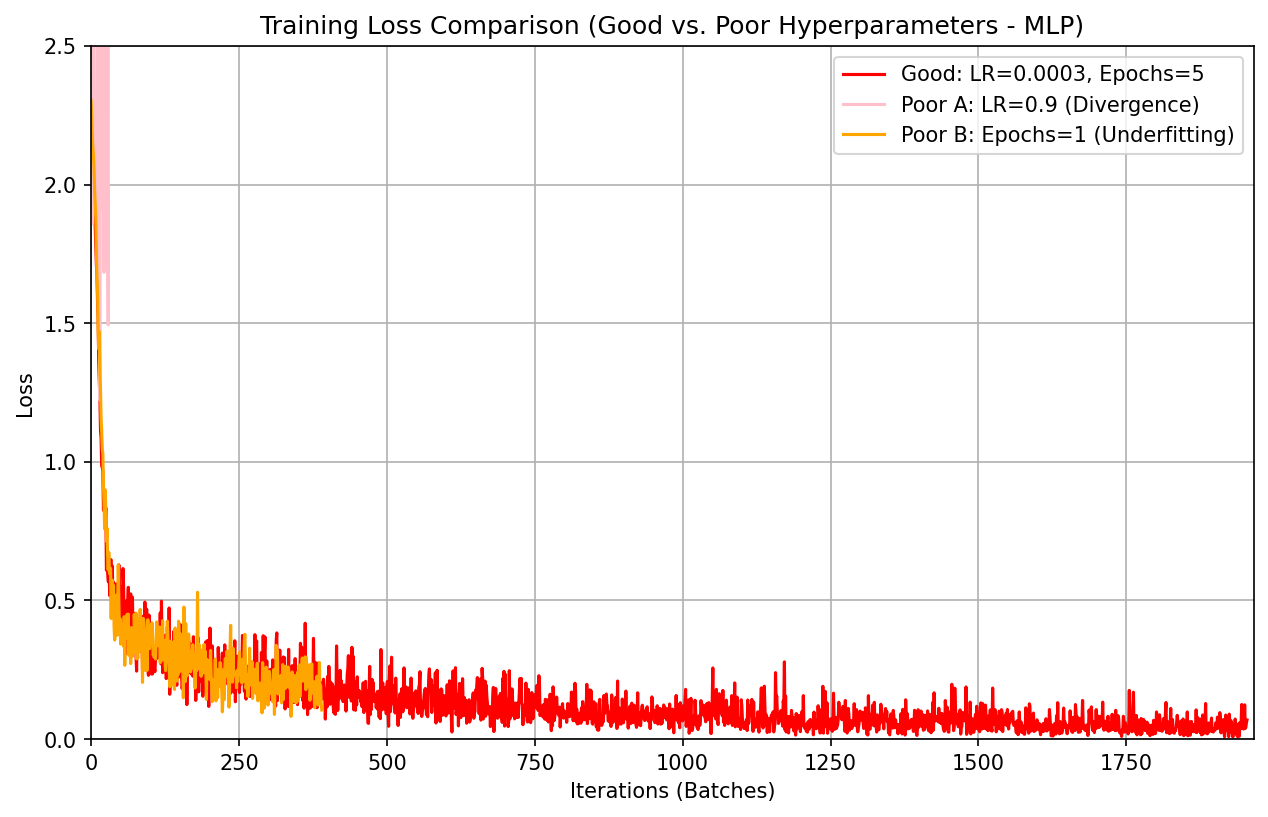

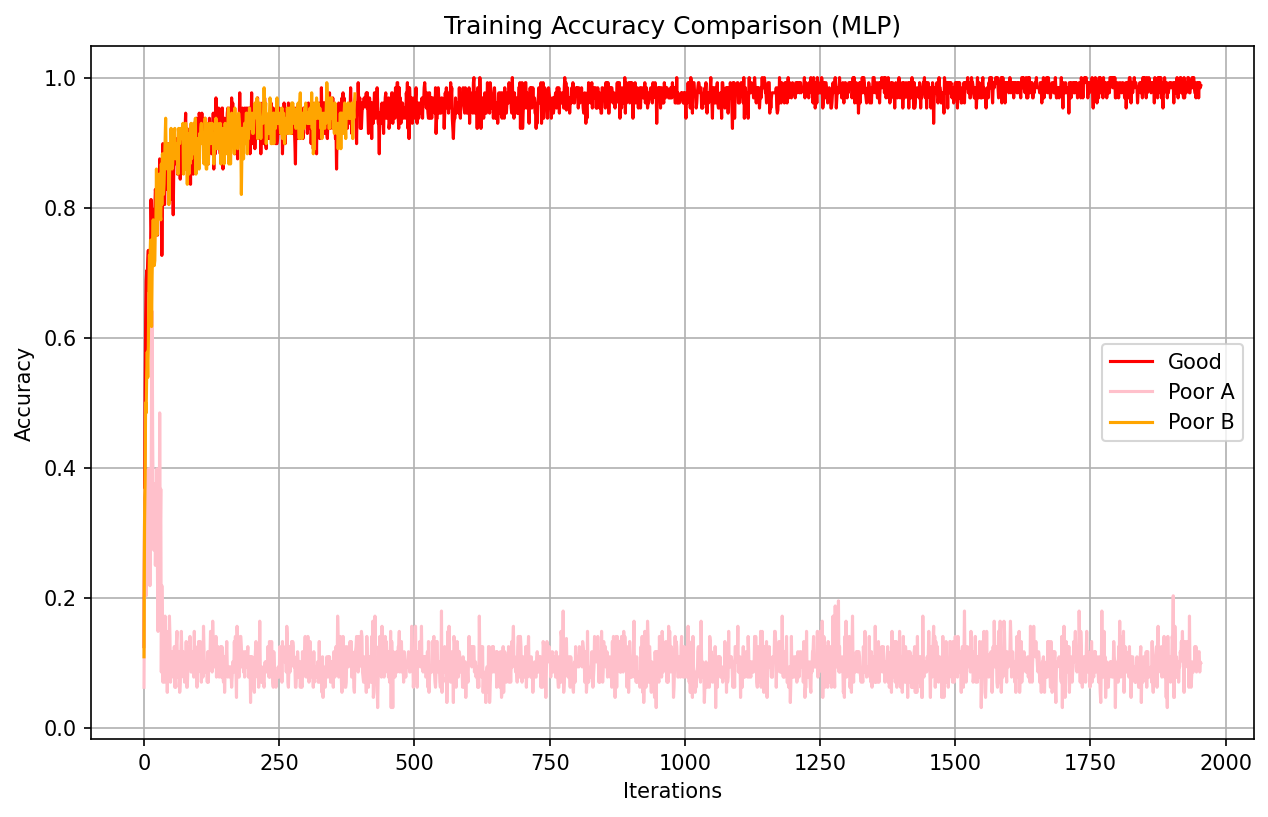

In [24]:
LR_GOOD = 3e-4
NUM_EPOCHS_GOOD = 5 

# Poor Parameters A
LR_POOR_A = 0.9
NUM_EPOCHS_POOR_A = 5

# Poor Parameters B
LR_POOR_B = 3e-4
NUM_EPOCHS_POOR_B = 1 

# NN 
model_good = Net().to(device)
optimizer_good = optim.Adam(model_good.parameters(), lr=LR_GOOD)

all_losses_good = []
all_accs_good = []

for epoch in range(NUM_EPOCHS_GOOD):
    print(f"MLP Good - Epoch {epoch + 1}/{NUM_EPOCHS_GOOD}")
    losses, accs = train(model_good, device, train_loader, optimizer_good, epoch)
    all_losses_good.extend(losses)
    all_accs_good.extend(accs)

    val_loss, val_acc = evaluate(model_good, device, val_loader)
    print(f"MLP Validation (Good): loss={val_loss:.4f}, acc={val_acc:.2f}%")

torch.save(model_good.state_dict(), "mlp_best_model.pth")

# NN poor parameter A
model_poor_A = Net().to(device)
optimizer_poor_A = optim.SGD(model_poor_A.parameters(), lr=LR_POOR_A)

all_losses_poor_A = []
all_accs_poor_A = []

for epoch in range(NUM_EPOCHS_POOR_A):
    print(f"MLP Poor A - Epoch {epoch + 1}/{NUM_EPOCHS_POOR_A}")
    losses, accs = train(model_poor_A, device, train_loader, optimizer_poor_A, epoch)
    all_losses_poor_A.extend(losses)
    all_accs_poor_A.extend(accs)

    val_loss, val_acc = evaluate(model_poor_A, device, val_loader)
    print(f"MLP Validation (Poor A): loss={val_loss:.4f}, acc={val_acc:.2f}%")


# NN poor parameter B
model_poor_B = Net().to(device)
optimizer_poor_B = optim.Adam(model_poor_B.parameters(), lr=LR_POOR_B)

all_losses_poor_B = []
all_accs_poor_B = []

for epoch in range(NUM_EPOCHS_POOR_B):
    print(f"MLP Poor B - Epoch {epoch + 1}/{NUM_EPOCHS_POOR_B}")
    losses, accs = train(model_poor_B, device, train_loader, optimizer_poor_B, epoch)
    all_losses_poor_B.extend(losses)
    all_accs_poor_B.extend(accs)

    val_loss, val_acc = evaluate(model_poor_B, device, val_loader)
    print(f"MLP Validation (Poor B): loss={val_loss:.4f}, acc={val_acc:.2f}%")

# Plot Comparison
plt.figure(figsize=(10, 6), dpi=150)
plt.plot(all_losses_good, label=f"Good: LR={LR_GOOD}, Epochs={NUM_EPOCHS_GOOD}", color='red')
plt.plot(all_losses_poor_A, label=f"Poor A: LR={LR_POOR_A} (Divergence)", color='pink')
plt.plot(all_losses_poor_B, label=f"Poor B: Epochs={NUM_EPOCHS_POOR_B} (Underfitting)", color='orange')

plt.title('Training Loss Comparison (Good vs. Poor Hyperparameters - MLP)')
plt.xlabel('Iterations (Batches)')
plt.ylabel('Loss')
plt.xlim(0, len(all_losses_good) + 10) 
plt.ylim(0, 2.5) 
plt.legend()
plt.grid(True)

plt.savefig("figures/NN_loss_comparison.png", dpi=300, bbox_inches="tight") #saving
plt.show() #plot 

plt.figure(figsize=(10, 6), dpi=150)
plt.plot(all_accs_good, label="Good", color= 'red')
plt.plot(all_accs_poor_A, label="Poor A",  color= 'pink')
plt.plot(all_accs_poor_B, label="Poor B",  color= 'orange')

plt.title("Training Accuracy Comparison (MLP)")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("figures/NN_training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

CNN Good - Epoch 1/5


100%|████████████████████████████████████████████████████████| 391/391 [01:02<00:00,  6.24it/s, loss=0.0632, acc=0.975]


CNN Validation (Good): loss=0.0920, acc=97.41%
CNN Good - Epoch 2/5


100%|████████████████████████████████████████████████████████| 391/391 [01:02<00:00,  6.30it/s, loss=0.0397, acc=0.975]


CNN Validation (Good): loss=0.0650, acc=97.99%
CNN Good - Epoch 3/5


...

CNN Validation (Poor A): loss=2.3025, acc=11.51%
CNN Poor A - Epoch 5/5


100%|████████████████████████████████████████████████████████████| 391/391 [01:04<00:00,  6.10it/s, loss=2.31, acc=0.1]


CNN Validation (Poor A): loss=2.3022, acc=10.37%
CNN Poor B - Epoch 1/1


100%|█████████████████████████████████████████████████████████| 391/391 [01:01<00:00,  6.37it/s, loss=0.187, acc=0.925]


CNN Validation (Poor B): loss=0.1005, acc=97.02%


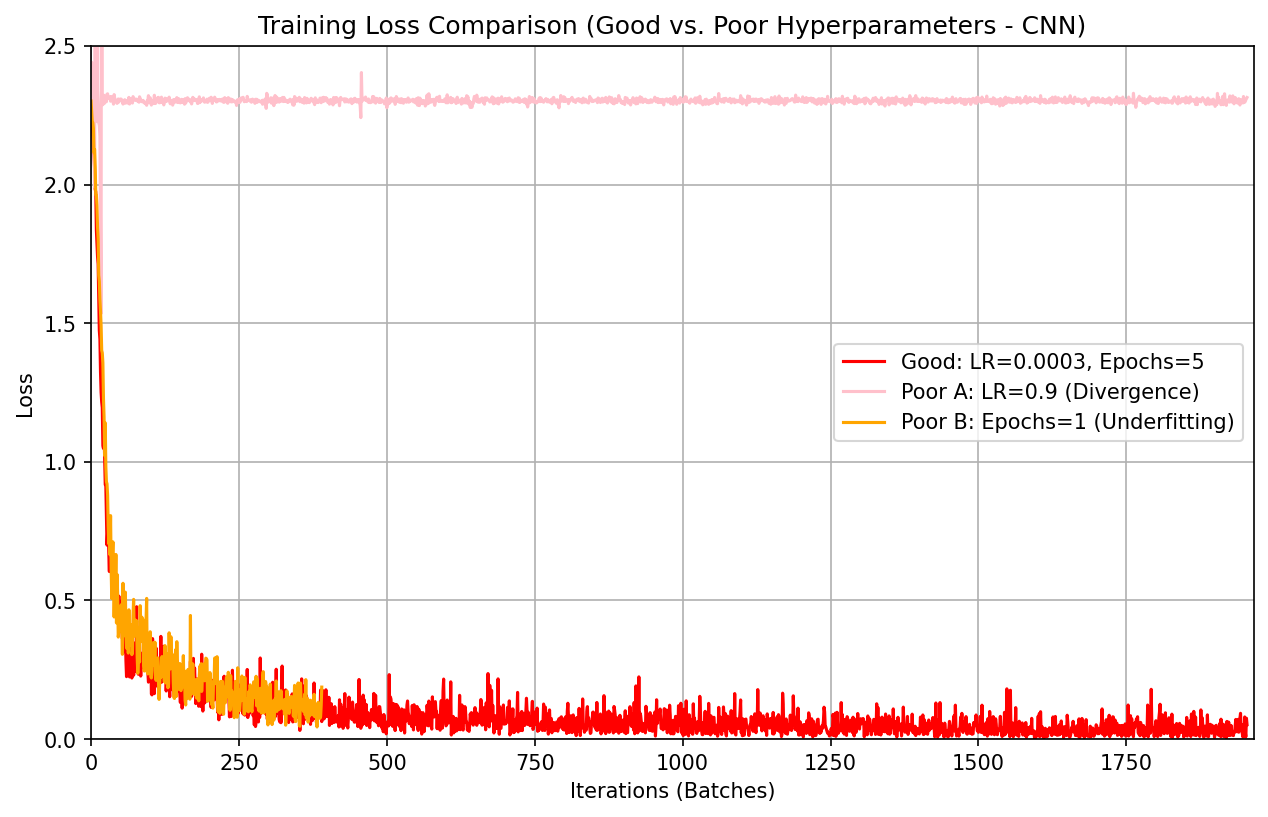

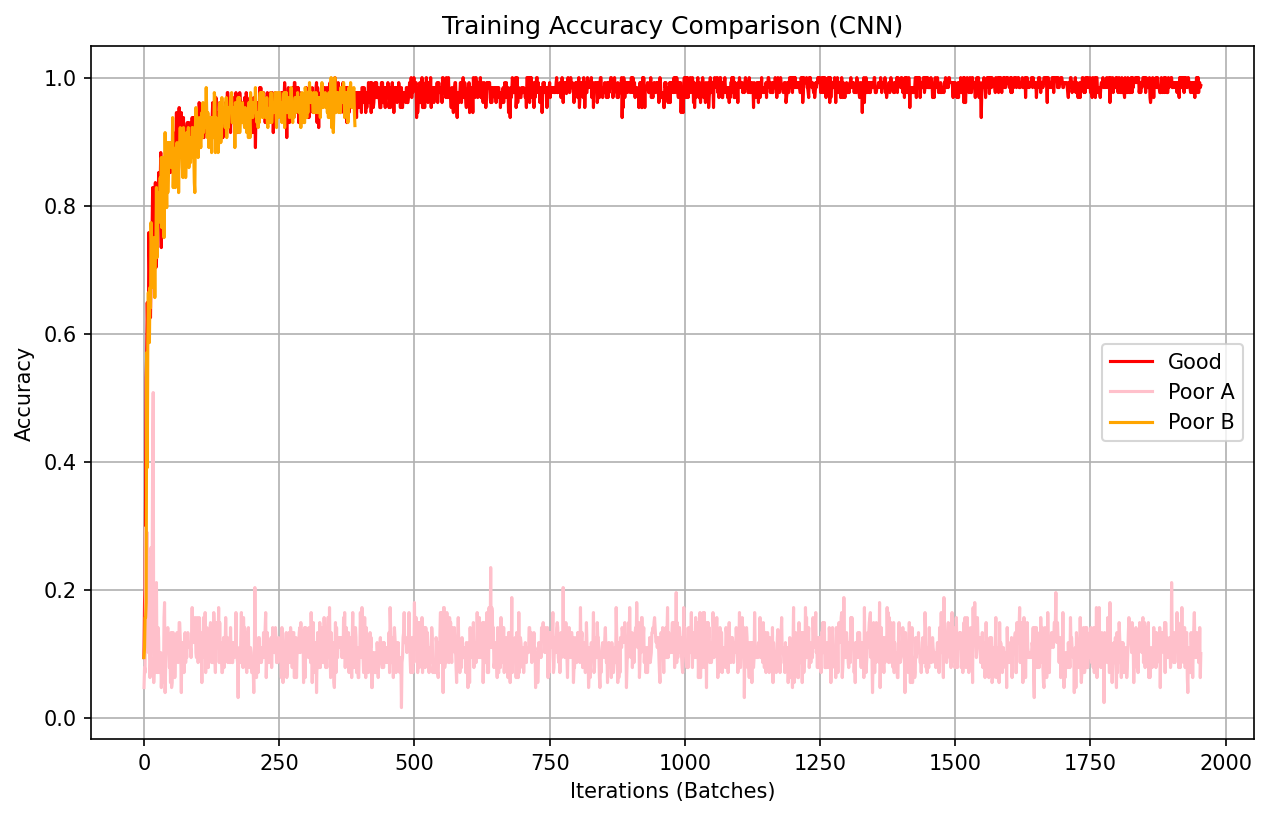

CNN Final Test: loss=0.0363, acc=98.81%


In [17]:
# CNN 
# Training CNN good Model
model_cnn_good = CNNNet().to(device)
optimizer_cnn_good = optim.Adam(model_cnn_good.parameters(), lr=LR_GOOD)

all_losses_cnn_good = []
all_accs_cnn_good = []

for epoch in range(NUM_EPOCHS_GOOD):
    print(f"CNN Good - Epoch {epoch + 1}/{NUM_EPOCHS_GOOD}")
    losses, accs = train(model_cnn_good, device, train_loader, optimizer_cnn_good, epoch)
    all_losses_cnn_good.extend(losses)
    all_accs_cnn_good.extend(accs)
    val_loss, val_acc = evaluate(model_cnn_good, device, val_loader)
    print(f"CNN Validation (Good): loss={val_loss:.4f}, acc={val_acc:.2f}%")

torch.save(model_cnn_good.state_dict(), "cnn_best_model.pth")

# CNN poor model A
model_cnn_poor_A = CNNNet().to(device)
optimizer_cnn_poor_A = optim.SGD(model_cnn_poor_A.parameters(), lr=LR_POOR_A)

all_losses_cnn_poor_A = []
all_accs_cnn_poor_A = []

for epoch in range(NUM_EPOCHS_POOR_A):
    print(f"CNN Poor A - Epoch {epoch + 1}/{NUM_EPOCHS_POOR_A}")
    losses, accs = train(model_cnn_poor_A, device, train_loader, optimizer_cnn_poor_A, epoch)
    all_losses_cnn_poor_A.extend(losses)
    all_accs_cnn_poor_A.extend(accs)
    val_loss, val_acc = evaluate(model_cnn_poor_A, device, val_loader)
    print(f"CNN Validation (Poor A): loss={val_loss:.4f}, acc={val_acc:.2f}%")
    
# CNN poor model B
model_cnn_poor_B = CNNNet().to(device)
optimizer_cnn_poor_B = optim.Adam(model_cnn_poor_B.parameters(), lr=LR_POOR_B)

all_losses_cnn_poor_B = []
all_accs_cnn_poor_B = []

for epoch in range(NUM_EPOCHS_POOR_B):
    print(f"CNN Poor B - Epoch {epoch + 1}/{NUM_EPOCHS_POOR_B}")
    losses, accs = train(model_cnn_poor_B, device, train_loader, optimizer_cnn_poor_B, epoch)
    all_losses_cnn_poor_B.extend(losses)
    all_accs_cnn_poor_B.extend(accs)
    val_loss, val_acc = evaluate(model_cnn_poor_B, device, val_loader)
    print(f"CNN Validation (Poor B): loss={val_loss:.4f}, acc={val_acc:.2f}%")

# Plot Comparison
plt.figure(figsize=(10, 6), dpi=150)
plt.plot(all_losses_cnn_good, label=f"Good: LR={LR_GOOD}, Epochs={NUM_EPOCHS_GOOD}", color='red')
plt.plot(all_losses_cnn_poor_A, label=f"Poor A: LR={LR_POOR_A} (Divergence)", color='pink')
plt.plot(all_losses_cnn_poor_B, label=f"Poor B: Epochs={NUM_EPOCHS_POOR_B} (Underfitting)", color='orange')

plt.title('Training Loss Comparison (Good vs. Poor Hyperparameters - CNN)')
plt.xlabel('Iterations (Batches)')
plt.ylabel('Loss')
plt.xlim(0, len(all_losses_cnn_good) + 10) 
plt.ylim(0, 2.5) 
plt.legend()
plt.grid(True)

plt.savefig("figures/cnn_loss_comparison.png", dpi=300, bbox_inches="tight")
plt.show() #plot


# Plot Training Accuracy
plt.figure(figsize=(10, 6), dpi=150)
plt.plot(all_accs_cnn_good, label="Good", color='red')
plt.plot(all_accs_cnn_poor_A, label="Poor A", color='pink')
plt.plot(all_accs_cnn_poor_B, label="Poor B", color='orange')

plt.title('Training Accuracy Comparison (CNN)')
plt.xlabel('Iterations (Batches)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig("figures/cnn_training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


test_loss, test_acc = evaluate(model_cnn_good, device, test_loader)
print(f"CNN Final Test: loss={test_loss:.4f}, acc={test_acc:.2f}%")


### Final evaluation and Comparison

FINAL TEST SET ACCURACY
MLP Final Test: loss=0.0712, acc=97.73%
CNN Final Test: loss=0.0363, acc=98.81%


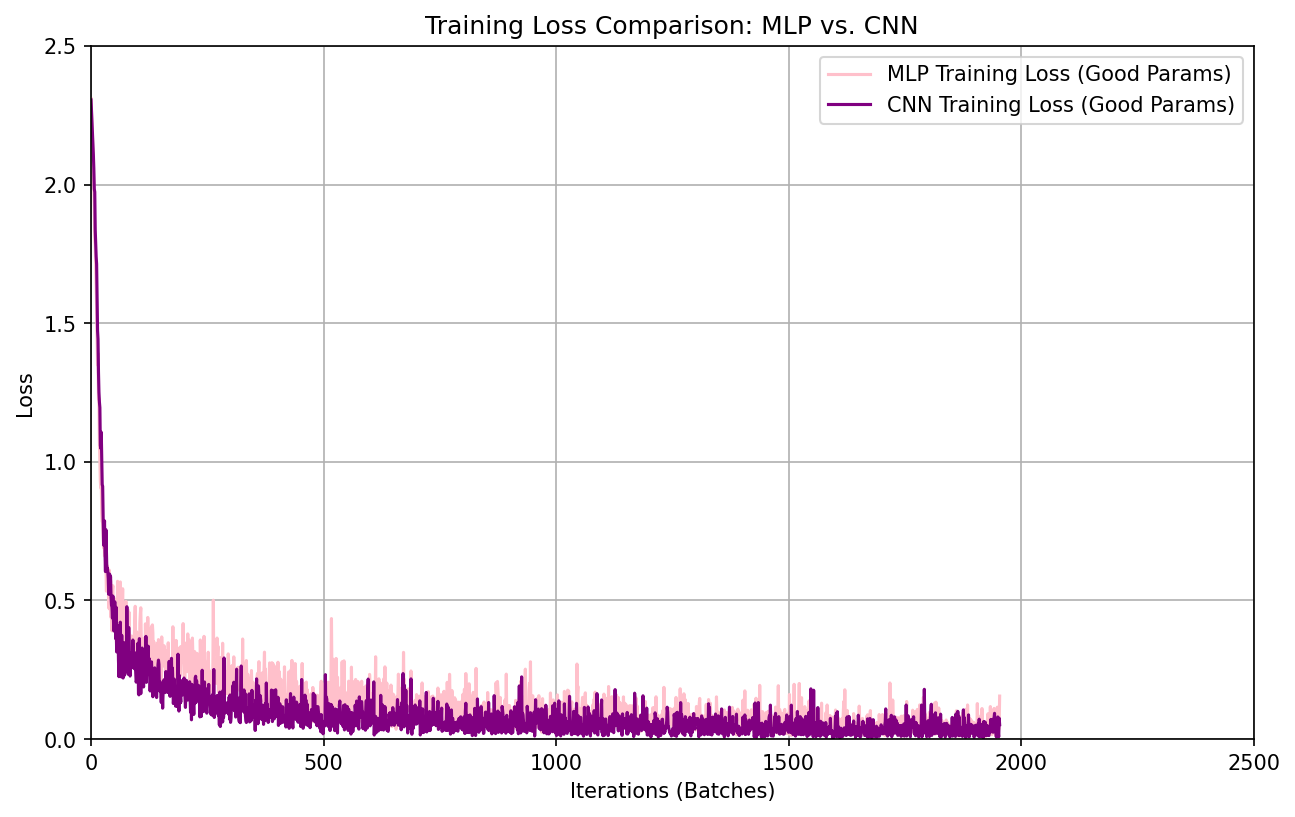

In [21]:
# Final evaluation
print("FINAL TEST SET ACCURACY")

# load best NN model for final test evaluation
model_good.load_state_dict(torch.load("mlp_best_model.pth", map_location=device))
model_good.to(device)
model_good.eval()

# load best CNN model for final test evaluation
model_cnn_good.load_state_dict(torch.load("cnn_best_model.pth", map_location=device))
model_cnn_good.to(device)
model_cnn_good.eval()


test_loss_mlp, test_acc_mlp = evaluate(model_good, device, test_loader)
print(f"MLP Final Test: loss={test_loss_mlp:.4f}, acc={test_acc_mlp:.2f}%")

test_loss_cnn, test_acc_cnn = evaluate(model_cnn_good, device, test_loader)
print(f"CNN Final Test: loss={test_loss_cnn:.4f}, acc={test_acc_cnn:.2f}%")


# Plotting: NN vs. CNN COMPARISON 
plt.figure(figsize=(10, 6), dpi=150)

# Plot the training loss 
plt.plot(all_losses_good, label='MLP Training Loss (Good Params)', color='pink')
plt.plot(all_losses_cnn_good, label='CNN Training Loss (Good Params)', color='purple')

plt.title('Training Loss Comparison: MLP vs. CNN')
          
plt.xlabel('Iterations (Batches)')
plt.ylabel('Loss')


plt.xlim(0, 2500) 
plt.ylim(0, 2.5) 
plt.legend()
plt.grid(True)
plt.savefig("figures/mlp_vs_cnn_training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

### Plot of prediction and images

NN Predictions:


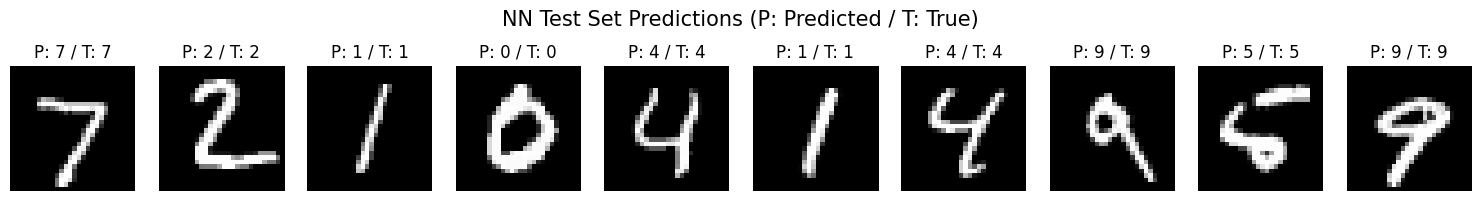

CNN Predictions:


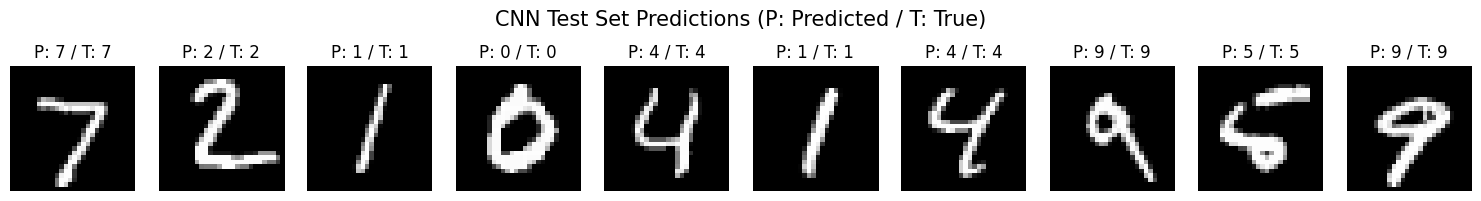

In [22]:
#plotting prediction with images

def plot_test_predictions(model, test_loader, device, num_images=10):
    model.eval()  
    try:
        images, labels = next(iter(test_loader))
    except StopIteration:
        test_loader_new = torch.utils.data.DataLoader(test_loader.dataset, batch_size=test_loader.batch_size)
        images, labels = next(iter(test_loader_new))
        
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():  
        outputs = model(images)  
        _, preds = torch.max(outputs, 1)  

    fig, axes = plt.subplots(1, num_images, figsize=(15, 2))
    model_name = "NN" if isinstance(model, Net) else "CNN" 
    fig.suptitle(f"{model_name} Test Set Predictions (P: Predicted / T: True)", fontsize=15)
    
    for i in range(num_images):
        ax = axes[i]
        ax.imshow(images[i].cpu().squeeze(), cmap="gray")  
        ax.set_title(f"P: {preds[i].item()} / T: {labels[i].item()}") 
        ax.axis("off")
        
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"{model_name}_predictions.png", dpi=300, bbox_inches="tight")


    plt.show()
    

print("NN Predictions:")
plot_test_predictions(model_good, test_loader, device, num_images=10)

print("CNN Predictions:")
plot_test_predictions(model_cnn_good, test_loader, device, num_images=10)